In [2]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader,TensorDataset

from tqdm import tqdm

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [5]:
df.drop("id",axis=1,inplace=True)

In [6]:
df.isnull().sum()

Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [7]:
df["Sex"] = pd.get_dummies(df["Sex"],dtype="int",drop_first=True)

In [8]:
df

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,36,189.0,82.0,26.0,101.0,41.0,150.0
1,0,64,163.0,60.0,8.0,85.0,39.7,34.0
2,0,51,161.0,64.0,7.0,84.0,39.8,29.0
3,1,20,192.0,90.0,25.0,105.0,40.7,140.0
4,0,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...
749995,1,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,0,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,1,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,1,45,182.0,91.0,17.0,102.0,40.3,109.0


In [9]:
x = df.drop("Calories",axis=1).values
y = df["Calories"].values

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
scaler_2 = StandardScaler()
y_train = scaler_2.fit_transform(y_train.reshape(-1,1))
y_test = scaler_2.transform(y_test.reshape(-1,1))

In [13]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [14]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

test_dataset = TensorDataset(
    x_test,
    y_test
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=100
)

test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=100
)

In [16]:
class ResidualBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.re1 = nn.Linear(dim,dim)
        self.ln1 = nn.LayerNorm(dim)

        self.re2 = nn.Linear(dim,dim)
        self.ln2 = nn.LayerNorm(dim)

        self.gelu = nn.ReLU()
    def forward(self,x):
        identity = x
        out = self.re1(x)
        out = self.ln1(out)
        out = self.gelu(out)

        out = self.re2(out)
        out = self.ln2(out)

        out = out + identity
        
        out = self.gelu(out)

        return out


In [17]:
class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.LayerNorm(128),
            nn.ReLU()
        )

        self.re1 = ResidualBlock(128)
        self.re2 = ResidualBlock(128)

        self.output = nn.Linear(128,1)

    def forward(self,x):
        x = self.fc1(x)

        x = self.re1(x)
        x = self.re2(x)

        x = self.output(x)
        return x

In [18]:
model = MyModel(input_dim=7)

In [19]:
model

MyModel(
  (fc1): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (re1): ResidualBlock(
    (re1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (re2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): ReLU()
  )
  (re2): ResidualBlock(
    (re1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (re2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): ReLU()
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

In [20]:
for name,parms in model.named_parameters():
    print(name,parms.shape)

fc1.0.weight torch.Size([128, 7])
fc1.0.bias torch.Size([128])
fc1.1.weight torch.Size([128])
fc1.1.bias torch.Size([128])
re1.re1.weight torch.Size([128, 128])
re1.re1.bias torch.Size([128])
re1.ln1.weight torch.Size([128])
re1.ln1.bias torch.Size([128])
re1.re2.weight torch.Size([128, 128])
re1.re2.bias torch.Size([128])
re1.ln2.weight torch.Size([128])
re1.ln2.bias torch.Size([128])
re2.re1.weight torch.Size([128, 128])
re2.re1.bias torch.Size([128])
re2.ln1.weight torch.Size([128])
re2.ln1.bias torch.Size([128])
re2.re2.weight torch.Size([128, 128])
re2.re2.bias torch.Size([128])
re2.ln2.weight torch.Size([128])
re2.ln2.bias torch.Size([128])
output.weight torch.Size([1, 128])
output.bias torch.Size([1])


In [21]:
for name,parms in model.named_parameters():
    print(name.upper())
    print("+====================+")
    print(parms.data)

FC1.0.WEIGHT
+====================+
tensor([[-0.0502, -0.3382, -0.3562, -0.2298,  0.1621,  0.1988,  0.3429],
        [-0.2237, -0.0191,  0.1658,  0.0694,  0.0300,  0.0400,  0.1809],
        [ 0.2923,  0.0516, -0.0198,  0.1646,  0.1278,  0.3382, -0.2691],
        [-0.0600, -0.2934, -0.3619, -0.2101,  0.2042,  0.3436,  0.2085],
        [-0.3468,  0.0819, -0.1601,  0.1258, -0.0660, -0.1081, -0.0909],
        [-0.1149,  0.2796,  0.3136,  0.3742,  0.2268, -0.3351, -0.3620],
        [ 0.2478, -0.2474, -0.2872, -0.1299,  0.3040,  0.3282, -0.3394],
        [-0.1356,  0.0678,  0.2825, -0.3179,  0.1556, -0.2427, -0.1237],
        [ 0.2161, -0.0712,  0.1653, -0.1585,  0.3388, -0.1488, -0.2105],
        [-0.2640, -0.3297,  0.3235,  0.2470,  0.2133, -0.1856,  0.0557],
        [ 0.3000, -0.2969, -0.2420,  0.0107,  0.3300,  0.1820, -0.1907],
        [ 0.0960, -0.2587,  0.1350, -0.1793,  0.0489, -0.2632,  0.1985],
        [ 0.3692, -0.2775,  0.2659, -0.1713, -0.2285,  0.3278, -0.0286],
        [-0.043

In [22]:
model.output

Linear(in_features=128, out_features=1, bias=True)

In [ ]:
#loss_function = nn.CrossEntropyLoss()
loss_function = nn.MSELoss()
optimizer_function = torch.optim.AdamW(model.parameters(),
                                       lr=0.001,
                                       weight_decay=0.01)

In [24]:
train_loss_hist = []
test_loss_hist = []

epochs = 20
process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimizer_function.zero_grad()
        prediction = model(batch_train_x)
        loss = loss_function(prediction,batch_train_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),
                                 max_norm=1.0)
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_x_test,batch_y_test in test_loader:
            test_prediction = model(batch_x_test)
            test_loss = loss_function(test_prediction,batch_y_test)
            total_test_loss += test_loss.item()
        avg_test_loss = total_test_loss / len(test_loader)

        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epoch":epoch,
            "Train Loss":avg_train_loss,
            "Test Loss":avg_test_loss,
            "Optimizer":optimizer_function.state_dict()
        },f"model_4/checkpoints_{epoch+1}.pth")

        process_bar.set_postfix({
            "Epoch":epoch+1,
            "Train Loss":f"{avg_train_loss:.4f}",
            "Test Loss":f"{avg_test_loss:.4f}"
        })

100%|██████████| 20/20 [09:42<00:00, 29.14s/it, Epoch=20, Train Loss=0.0042, Test Loss=0.0043]


In [44]:
model.eval()

MyModel(
  (fc1): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (re1): ResidualBlock(
    (re1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (re2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): ReLU()
  )
  (re2): ResidualBlock(
    (re1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (re2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): ReLU()
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

In [45]:
preds = []
actual = []

with torch.no_grad():
    for batch_x_testing,batch_y_testing in test_loader:
        output = model(batch_x_testing)

        preds.extend(output.squeeze().numpy())
        actual.extend(batch_y_testing.numpy())

In [48]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [55]:
mae = mean_absolute_error(actual,preds)
mse = mean_squared_error(actual,preds)**0.5
r2 = r2_score(actual,preds)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")

MAE: 0.040877360831722616
MSE: 0.06556802876989694
R2: 0.9956764878721391


In [50]:
mean

0.040877360831722616

In [25]:
"""train_loss_hist = []
test_loss_hist = []

epochs = 20
process_bar = tqdm(range(epochs),colour="blue")

for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_train_x,batch_train_y in train_loader:
        optimizer_function.zero_grad()
        train_prediction = model(batch_train_x)
        loss = loss_function(train_prediction,batch_train_y)
        loss.backward()
        #gradient clipping
        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss   / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch_test_x,batch_test_y in test_loader:
            test_prediction = model(batch_test_x)
            test_loss = loss_function(test_prediction,batch_test_y)
            total_test_loss += test_loss.item()
    avg_test_loss = total_test_loss / len(test_loader)
    
    train_loss_hist.append(avg_train_loss)
    test_loss_hist.append(avg_test_loss)

    torch.save({
      "Epochs":epoch,
      "Test Loss":avg_test_loss,
      "Train Loss":avg_train_loss,
      "Optimizer":optimizer_function.state_dict(),
      "Model":model.state_dict()  
    },f"residual_model/checkpoint_{epoch+1}.pth")

    process_bar.set_postfix({
        "Epoch":epoch+1,
        "Train Loss":f"{avg_train_loss:.4f}",
        "Test Loss":f"{avg_test_loss:.4f}"
    })"""


'train_loss_hist = []\ntest_loss_hist = []\n\nepochs = 20\nprocess_bar = tqdm(range(epochs),colour="blue")\n\nfor epoch in process_bar:\n    model.train()\n    total_train_loss = 0\n    for batch_train_x,batch_train_y in train_loader:\n        optimizer_function.zero_grad()\n        train_prediction = model(batch_train_x)\n        loss = loss_function(train_prediction,batch_train_y)\n        loss.backward()\n        #gradient clipping\n        nn.utils.clip_grad_norm_(\n            model.parameters(),\n            max_norm=1.0\n        )\n        optimizer_function.step()\n        total_train_loss += loss.item()\n    avg_train_loss = total_train_loss   / len(train_loader)\n\n    model.eval()\n    total_test_loss = 0\n    with torch.no_grad():\n        for batch_test_x,batch_test_y in test_loader:\n            test_prediction = model(batch_test_x)\n            test_loss = loss_function(test_prediction,batch_test_y)\n            total_test_loss += test_loss.item()\n    avg_test_loss = to

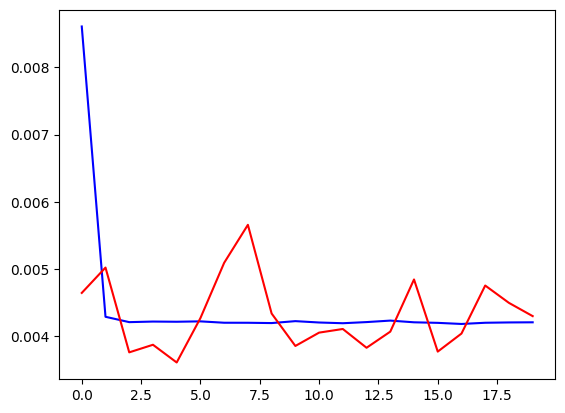

In [26]:
plt.plot(train_loss_hist,label="Train Loss",color="Blue")
plt.plot(test_loss_hist,label="Test Loss",color="red")

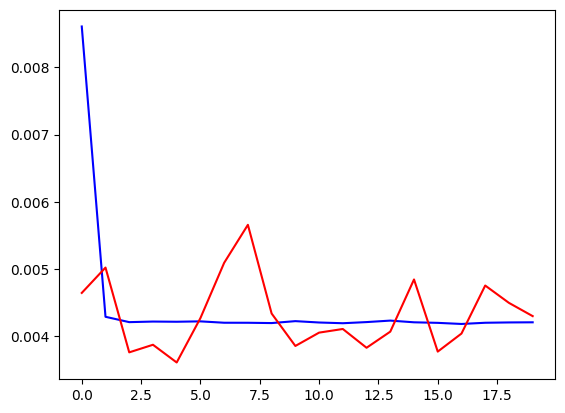

In [29]:
plt.plot(train_loss_hist,label="Train Loss",color="blue")
plt.plot(test_loss_hist,label="Test Loss",color="red")

## *****************************************SHAP

# Their are three levels of SHAP
## 1. Local Explanation  2. Global Explanation  3. Feature Interaction

In [30]:
import shap

In [31]:
model.eval()

MyModel(
  (fc1): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (re1): ResidualBlock(
    (re1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (re2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): ReLU()
  )
  (re2): ResidualBlock(
    (re1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (re2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (gelu): ReLU()
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)

In [34]:
background = x_train[:100]

In [33]:
background

tensor([[ 1.0017,  0.1039,  1.1929,  0.9907, -1.1275, -0.8977, -1.2002],
        [-0.9983,  0.4334, -1.5365, -1.5126, -0.4095,  0.1602,  0.2102],
        [ 1.0017,  0.6311,  0.9590,  1.2052, -0.0505,  0.0544,  0.5949],
        [ 1.0017,  0.2357,  0.5690,  0.9191, -1.6062, -1.3208, -2.2260],
        [ 1.0017, -1.2797,  2.1287,  1.7059,  1.1462,  0.2660,  0.8513],
        [-0.9983, -0.4232, -1.0686, -1.0835,  1.5052,  1.2180,  0.9796],
        [-0.9983,  2.4101, -0.5227, -0.4398,  0.5478,  1.8528,  0.3385],
        [-0.9983, -0.8185, -1.3025, -1.3696, -0.5292, -0.1572, -0.3027],
        [ 1.0017,  0.3675, -0.6787, -0.4398,  0.7872,  0.7949,  0.7231],
        [ 1.0017, -1.1480,  0.6470,  0.9191, -1.3668, -0.8977, -1.3284]])

In [37]:
explainer = shap.DeepExplainer(
    model,
    background
)

In [41]:
explainer.expected_value

array([-0.00119006], dtype=float32)

In [42]:
shap_values = explainer.shap_values(
    x_test[:20]
)

/home/anmino/.local/lib/python3.10/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")


AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 0.5256849783472717 - Tolerance: 0.01